## Bootstrap workspace

Resolve the shared notebook bootstrap so imports work from any repo root.


In [14]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


## Configure notebook runtime

Enable autoreload, import analysis libraries, and widen the notebook display.


In [15]:
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import time
import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load assay dataset

Fetch the selected PubChem assay graphs and targets used in the explanation example.


In [16]:
from abstractgraph_graphicalizer.chem import PubChemAssayLoader

loader = PubChemAssayLoader(on_error="skip")
assay_id = '624249'
graphs, targets = loader.load(assay_id)
print(f'AID{assay_id}  #graphs: {len(graphs)}')


AID624249  #graphs: 528


## Build decomposition recipe

Define the graph decomposition operators that will generate the feature space.


In [17]:
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.labels import graph_hash_label_function_factory, name_hash_label_function_factory
from abstractgraph.display import display, display_decomposition_graph, display_graph, display_mappings
from abstractgraph.operators import *


# label_mode options:
# - "graph_hash": hash the mapped image subgraph structure
# - "operator_hash": hash the operator/user-name metadata
def relabel_for_display(ag, *, nbits=11, label_mode="graph_hash"):
    display_ag = ag.copy()
    if label_mode == "graph_hash":
        display_ag.label_function = graph_hash_label_function_factory(nbits)
    elif label_mode == "operator_hash":
        display_ag.label_function = name_hash_label_function_factory(nbits)
    else:
        raise ValueError(f"Unknown label_mode: {label_mode}")
    display_ag.apply_label_function()
    return display_ag


def draw(graph, decomposition_function, *, nbits=11, label_mode="graph_hash", display_label_mode=None, size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(
        graph,
        decomposition_function=decomposition_function,
        nbits=nbits,
        label_mode=label_mode,
    )
    if display_label_mode is None:
        display_label_mode = label_mode
    display_ag = relabel_for_display(ag, nbits=nbits, label_mode=display_label_mode)
    display(display_ag, size=size)
    display_mappings(display_ag, n_elements_per_row=n_elements_per_row)
    return ag


## Inspect decomposition

Render the decomposition graph to verify the chosen operator structure.


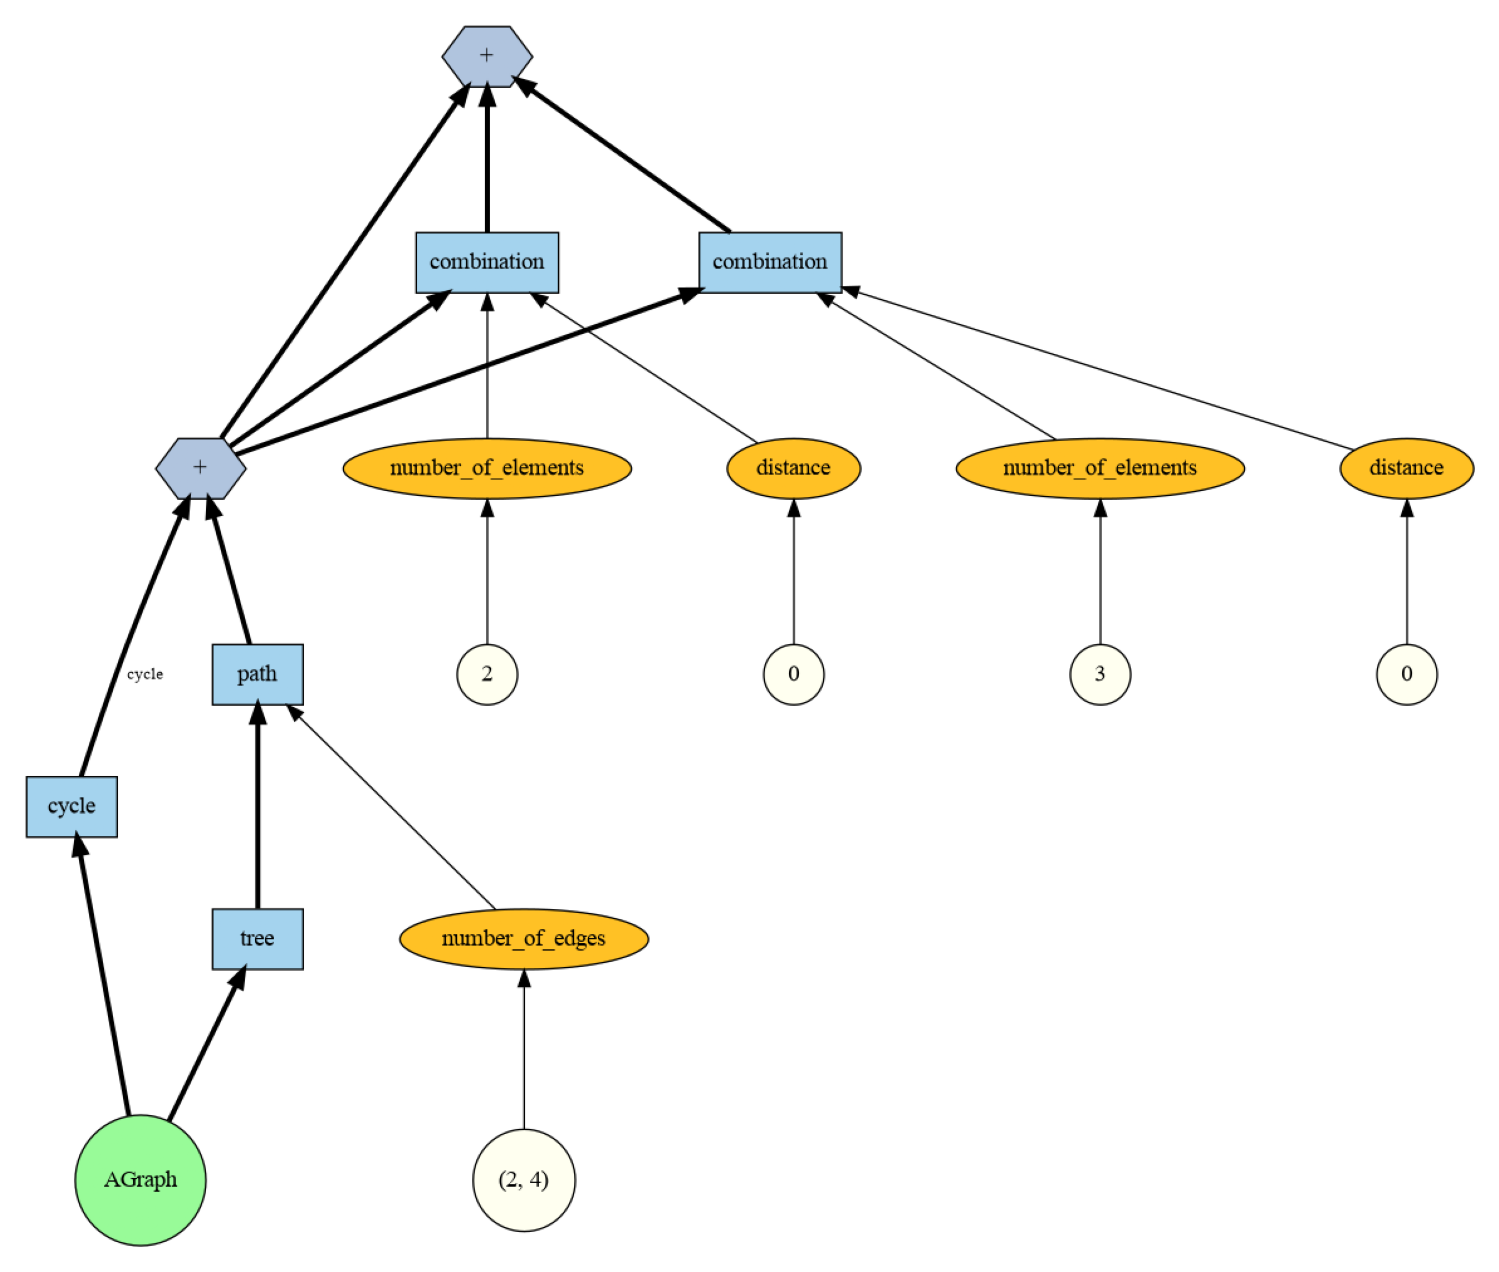

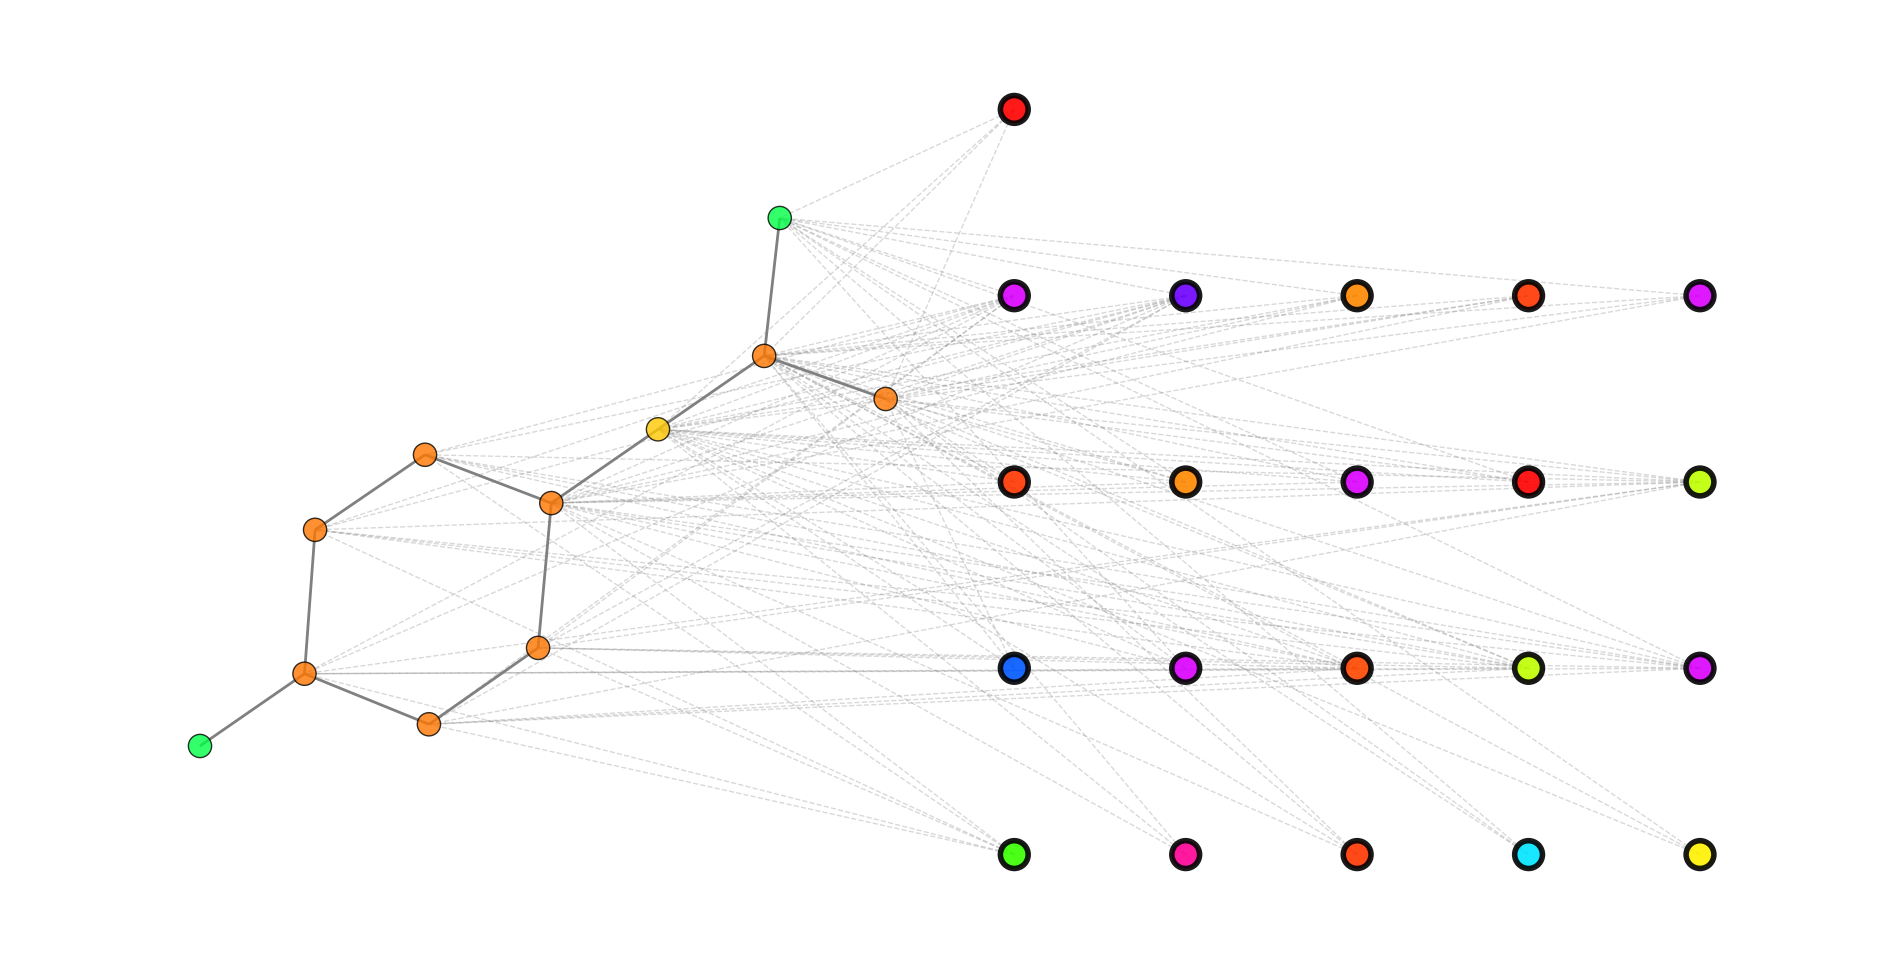

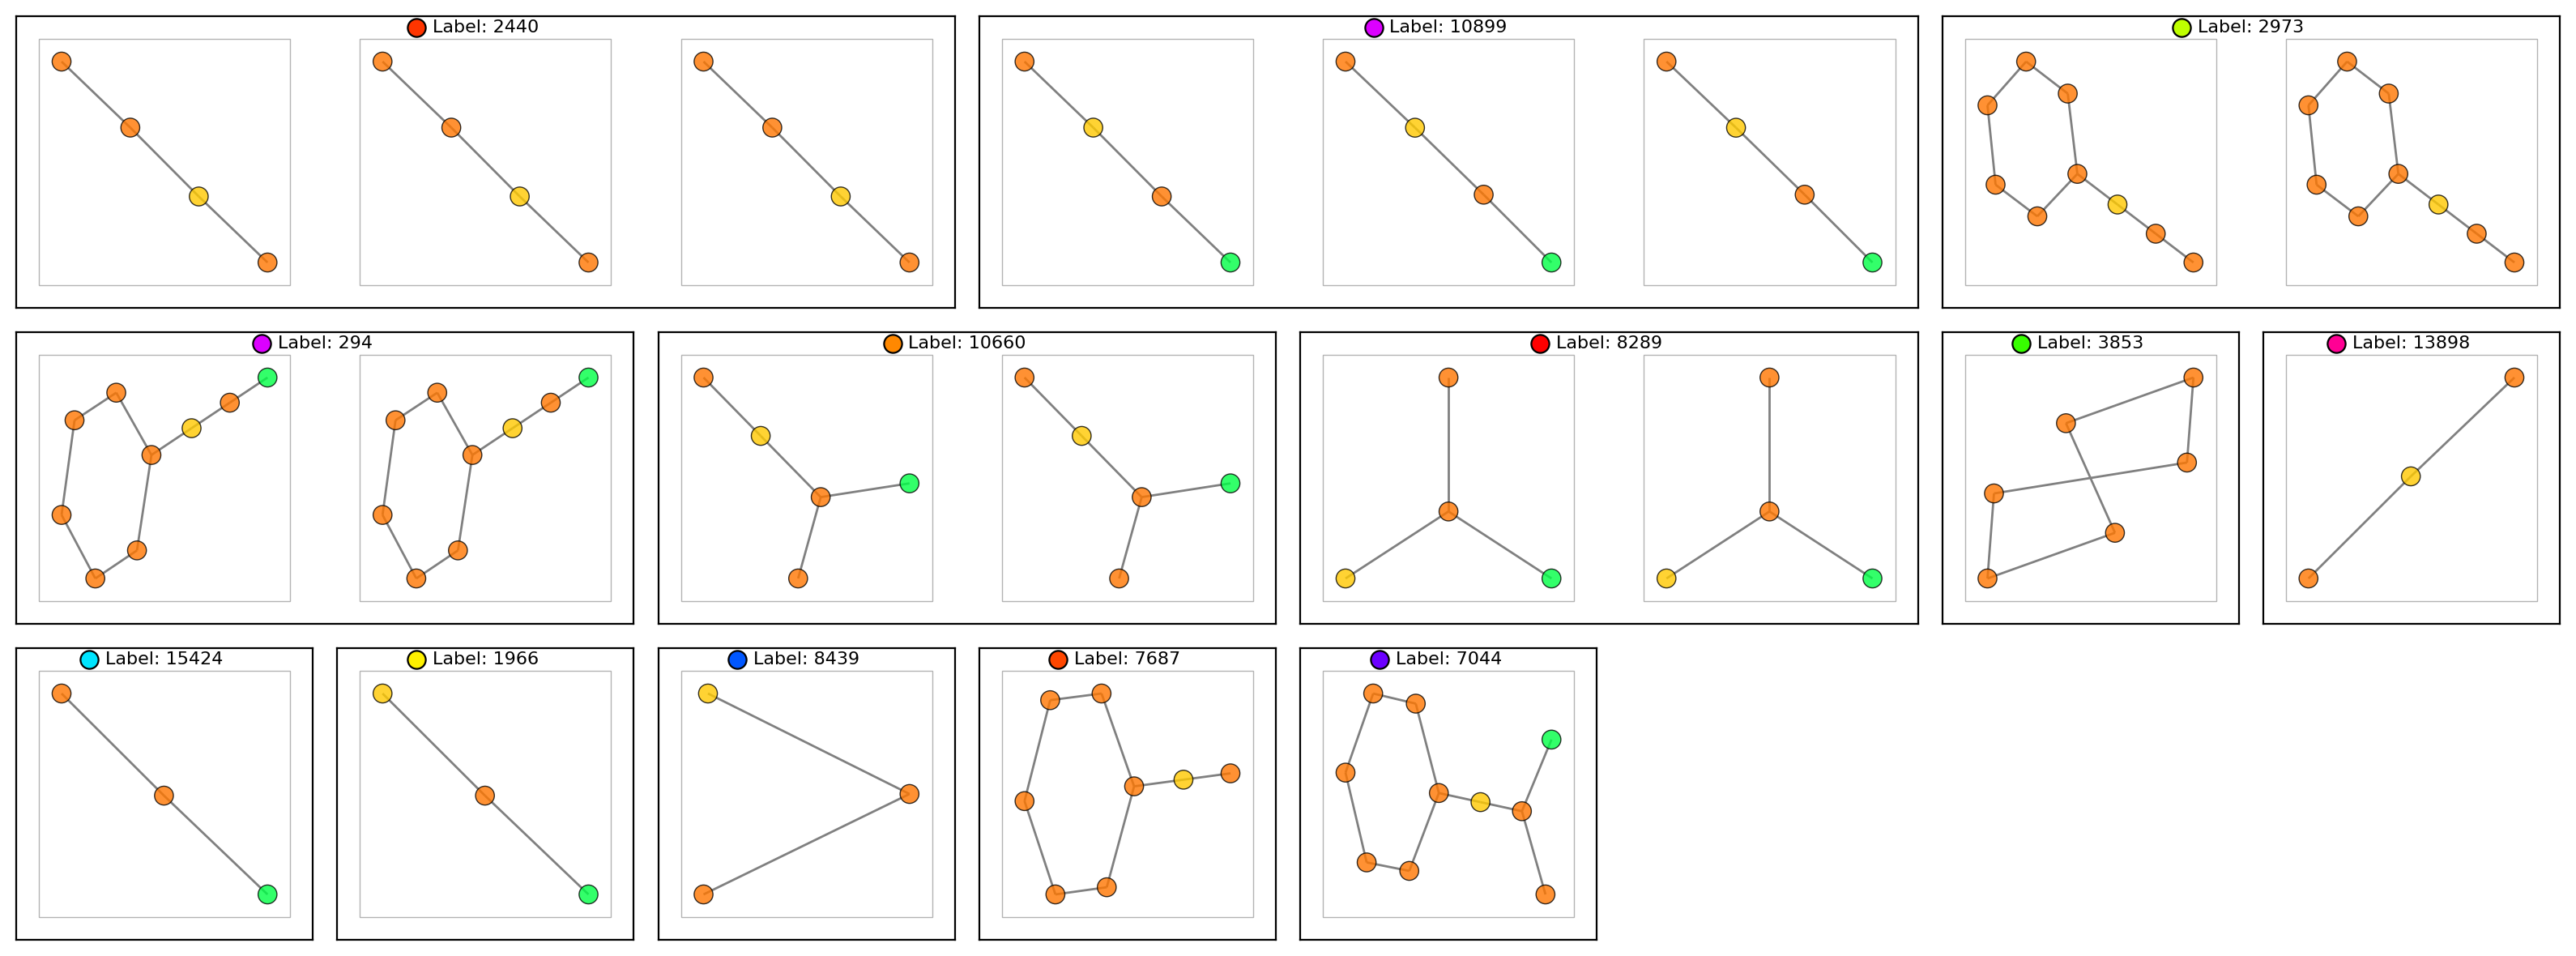

In [18]:
nbits = 14
df1 = add(cycle(), compose(path(number_of_edges=(2, 4)), tree()))
df2 = compose(combination(number_of_elements=2, distance=0), df1)
df3 = compose(combination(number_of_elements=3, distance=0), df1)
df = add(df1, df2, df3)

example_decomposition = draw(graphs[0], df, nbits=nbits)


## Create estimator pipeline

Assemble the graph transformer and random-forest estimator wrapper.


In [19]:
from abstractgraph.vectorize import AbstractGraphTransformer
from sklearn.ensemble import RandomForestClassifier
from abstractgraph_ml.estimators import GraphEstimator

transformer = AbstractGraphTransformer(
    nbits=nbits,
    decomposition_function=df,
    return_dense=True,
    n_jobs=-1,
)

graph_estimator = GraphEstimator(
    transformer=transformer,
    estimator=RandomForestClassifier(random_state=0, n_estimators=300, n_jobs=-1),
    manifold=None,
    n_selected_features=500,
)


## Train and evaluate

Split the dataset, fit the model, and report held-out performance.


In [20]:
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

targets = np.array(targets)
graphs_tr, graphs_te, targets_tr, targets_te = train_test_split(
    graphs,
    targets,
    test_size=0.2,
    random_state=0,
)
print(f'train={len(graphs_tr)}  test={len(graphs_te)}')

t_fit0 = time.perf_counter()
graph_estimator.fit(graphs_tr, targets_tr)
fit_time = time.perf_counter() - t_fit0

pred_te = graph_estimator.predict(graphs_te)
acc_te = accuracy_score(targets_te, pred_te)
print(f'accuracy={acc_te:.3f}  fit_time={fit_time:.2f}s')

proba_te = graph_estimator.predict_proba(graphs_te)
if proba_te.ndim == 2 and proba_te.shape[1] == 2:
    auc_te = roc_auc_score(targets_te, proba_te[:, 1])
    ap_te = average_precision_score(targets_te, proba_te[:, 1])
    print(f'roc_auc={auc_te:.3f}  avg_precision={ap_te:.3f}')


train=422  test=106
accuracy=0.736  fit_time=60.84s
roc_auc=0.715  avg_precision=0.834


## Select an example graph

Choose one held-out graph after fitting and summarize its prediction.


In [113]:
classes = graph_estimator.estimator_.classes_
class_to_col = {cls: i for i, cls in enumerate(classes)}
positive_class = 1 if 1 in class_to_col else classes[-1]
positive_proba = proba_te[:, class_to_col[positive_class]].astype(float)
sampling_weights = positive_proba / positive_proba.sum() if positive_proba.sum() > 0 else None
example_idx = int(np.random.choice(len(graphs_te), p=sampling_weights))
example_graph = graphs_te[example_idx]
example_target = int(targets_te[example_idx])
example_pred = int(pred_te[example_idx])
example_proba = {int(cls): float(proba_te[example_idx, class_to_col[cls]]) for cls in classes}
example_proba_str = ', '.join(f'{cls}: {prob:.3f}' for cls, prob in example_proba.items())
print(f'example_idx={example_idx}  target={example_target}  pred={example_pred}  pos_class={int(positive_class)}  proba={{ {example_proba_str} }}')


example_idx=62  target=1  pred=1  pos_class=1  proba={ 0: 0.107, 1: 0.893 }


## Visualize node saliency

Map the fitted feature ranking back onto the selected graph.


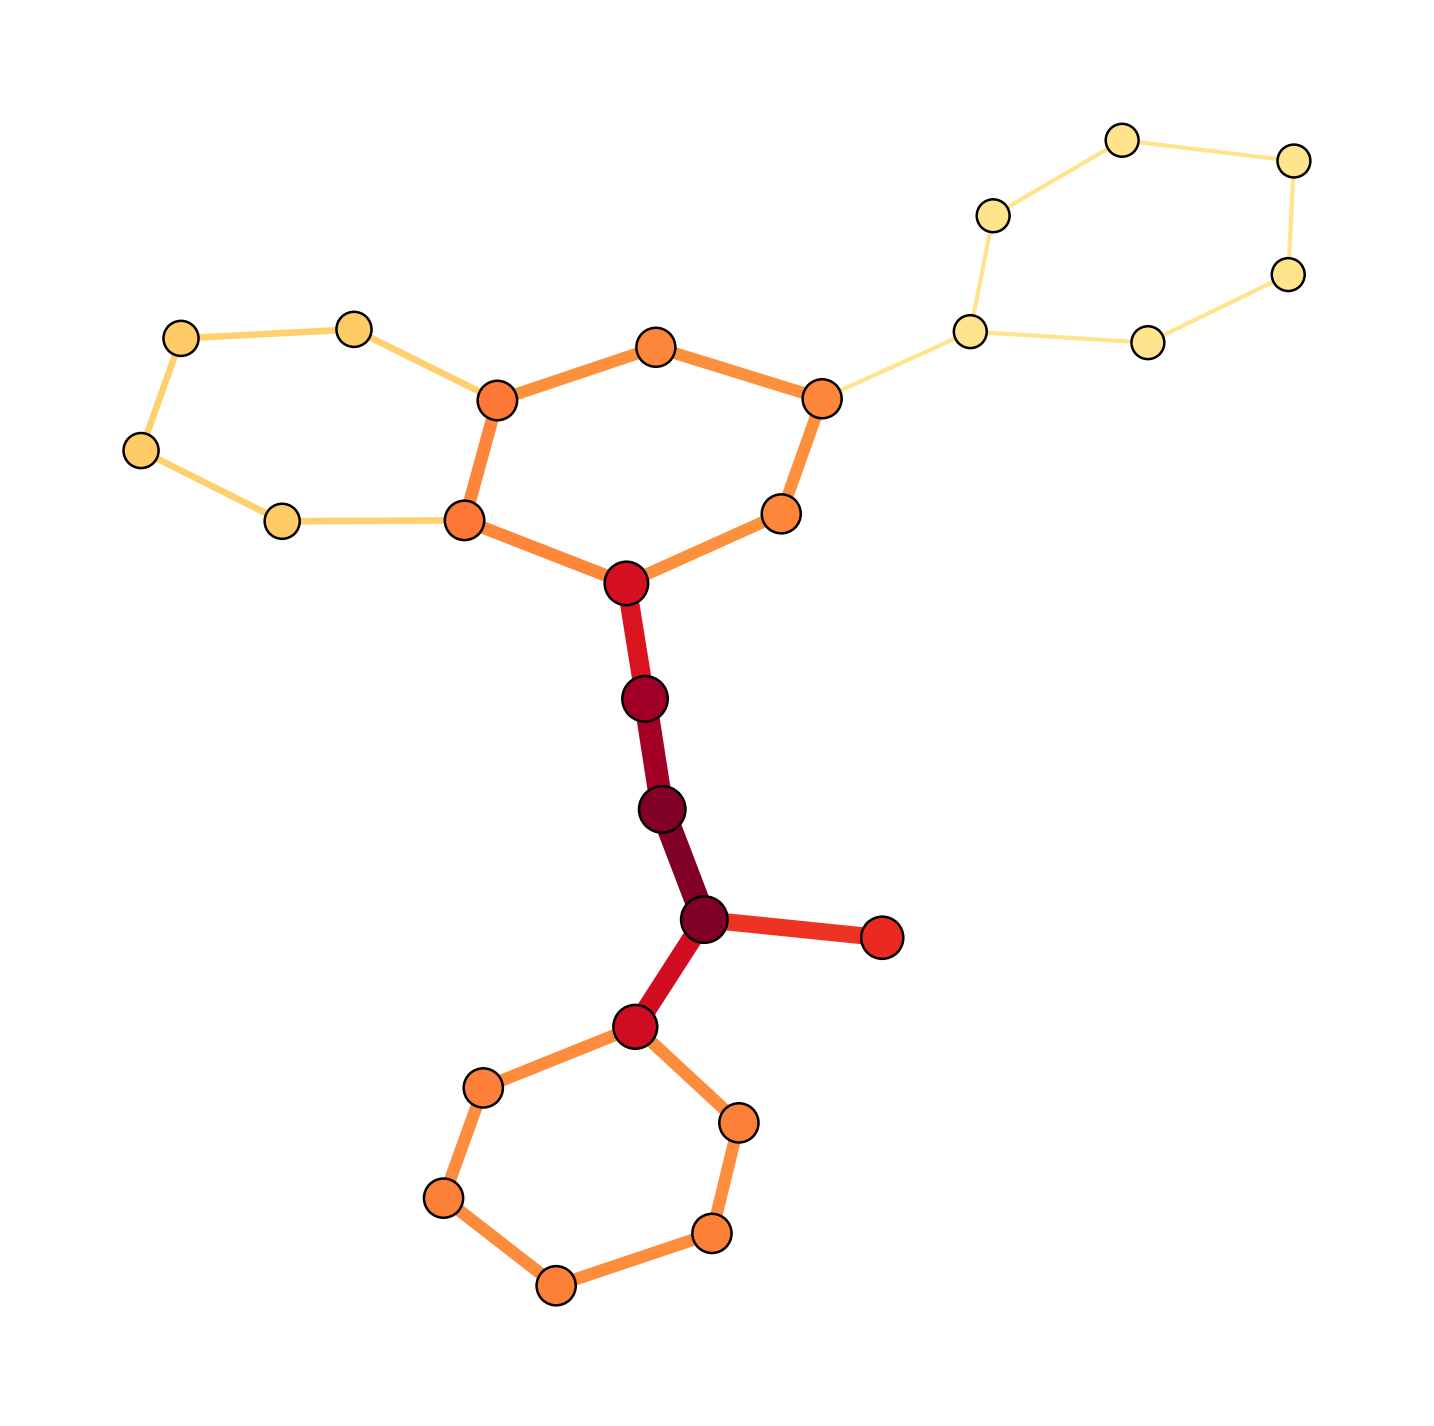

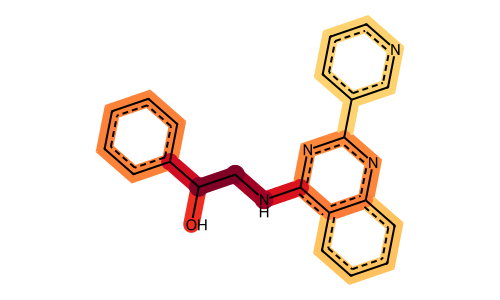

In [114]:
from IPython.display import display as ipy_display
from abstractgraph_graphicalizer.chem import draw_molecule
from abstractgraph_ml.importance import annotate_graph_node_saliency, plot_graph_node_saliency

annotated_graph, _, _ = annotate_graph_node_saliency(
    example_graph,
    graph_estimator,
    node_agg='sum',
    edge_stat='min',
)
_ = plot_graph_node_saliency(annotated_graph, cmap='YlOrRd', size=(9, 9))
ipy_display(draw_molecule(annotated_graph, cmap='YlOrRd', glow=True, size=(500, 300)))


## Rebuild interpretation nodes from ranked labels

Apply the new operator: marginalize ranked interpretation-label importance onto base nodes, keep the top base nodes, and emit connected components as fresh interpretation nodes.


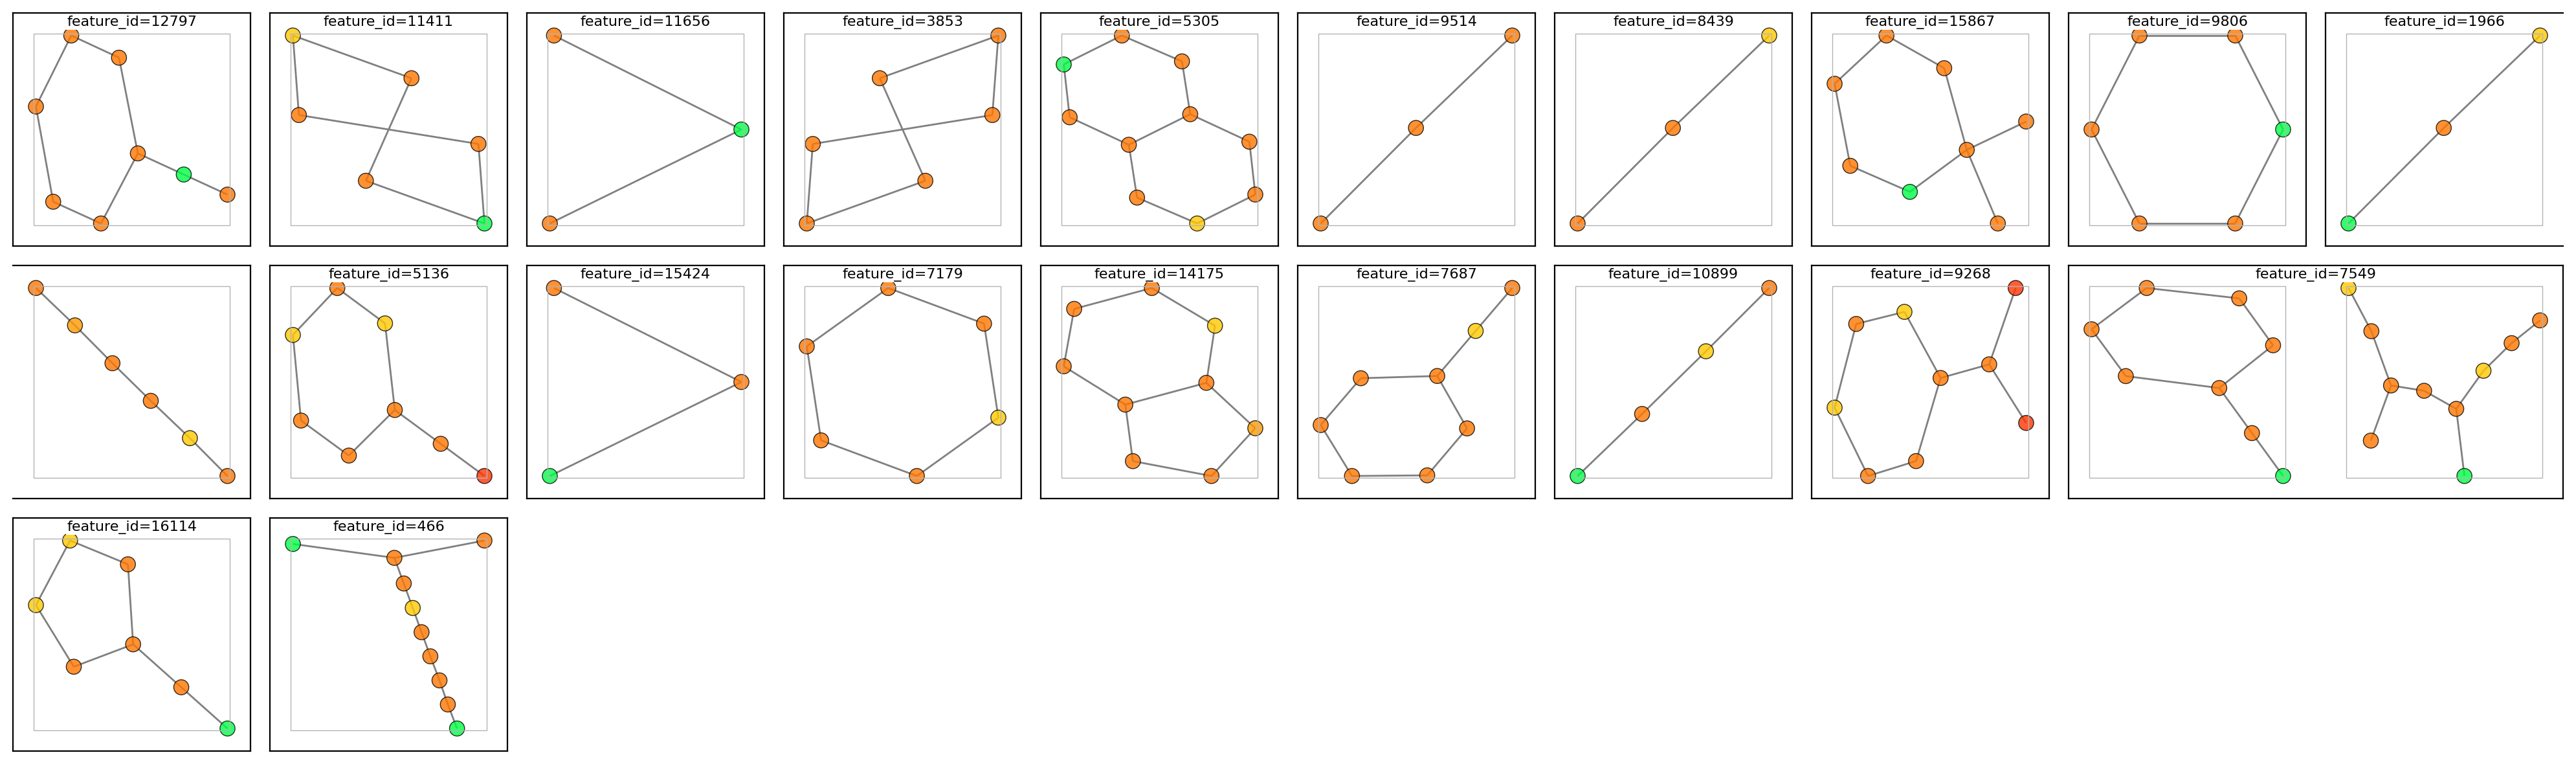

In [117]:
from abstractgraph_ml.importance import display_topk_feature_subgraphs

ranked_feature_ids = graph_estimator.get_ranked_feature_ids(fit_if_needed=False)
feature_importances = graph_estimator.get_feature_importances(fit_if_needed=False)

if True:
    _ = display_topk_feature_subgraphs(
        graphs=graphs_te,
        graph_estimator=graph_estimator,
        top_k_features=20,
        n_graphs_per_line=10,
        size=(2, 2),
    )

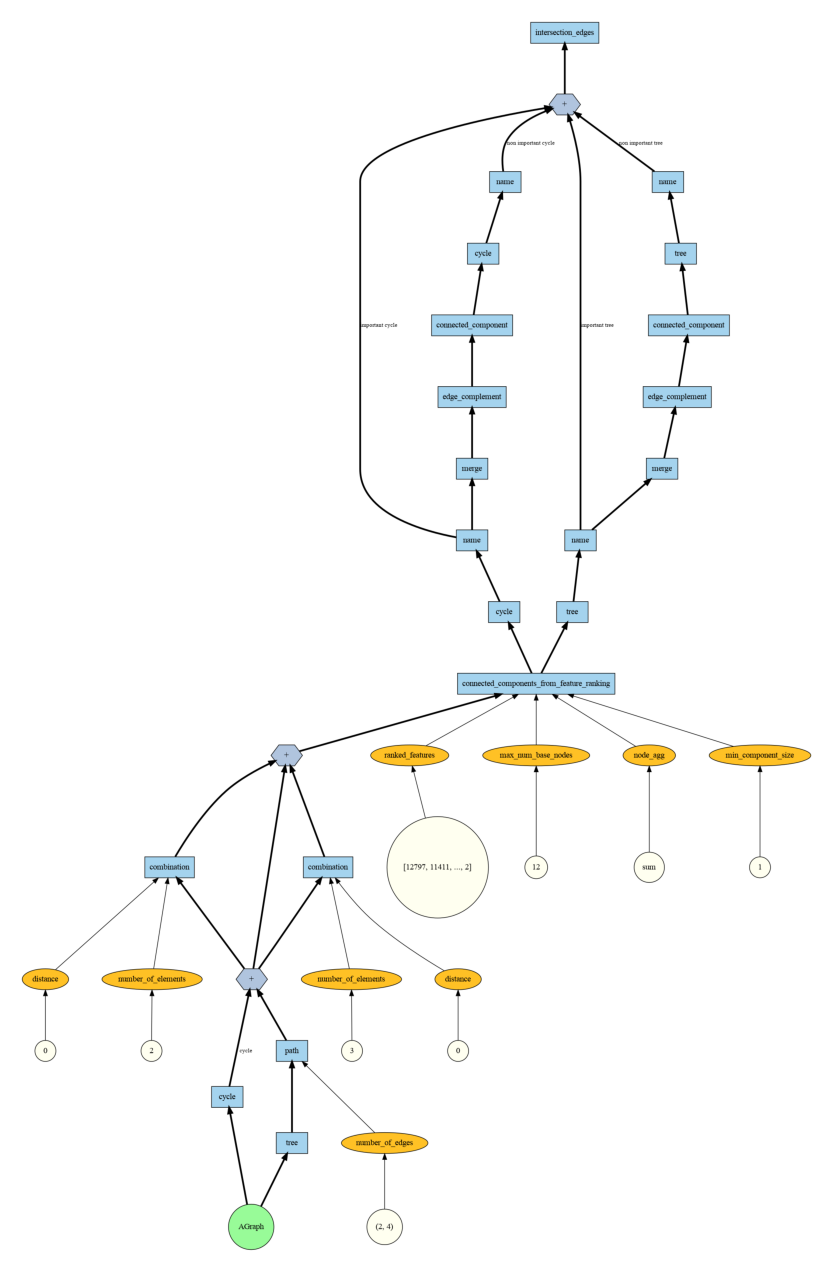

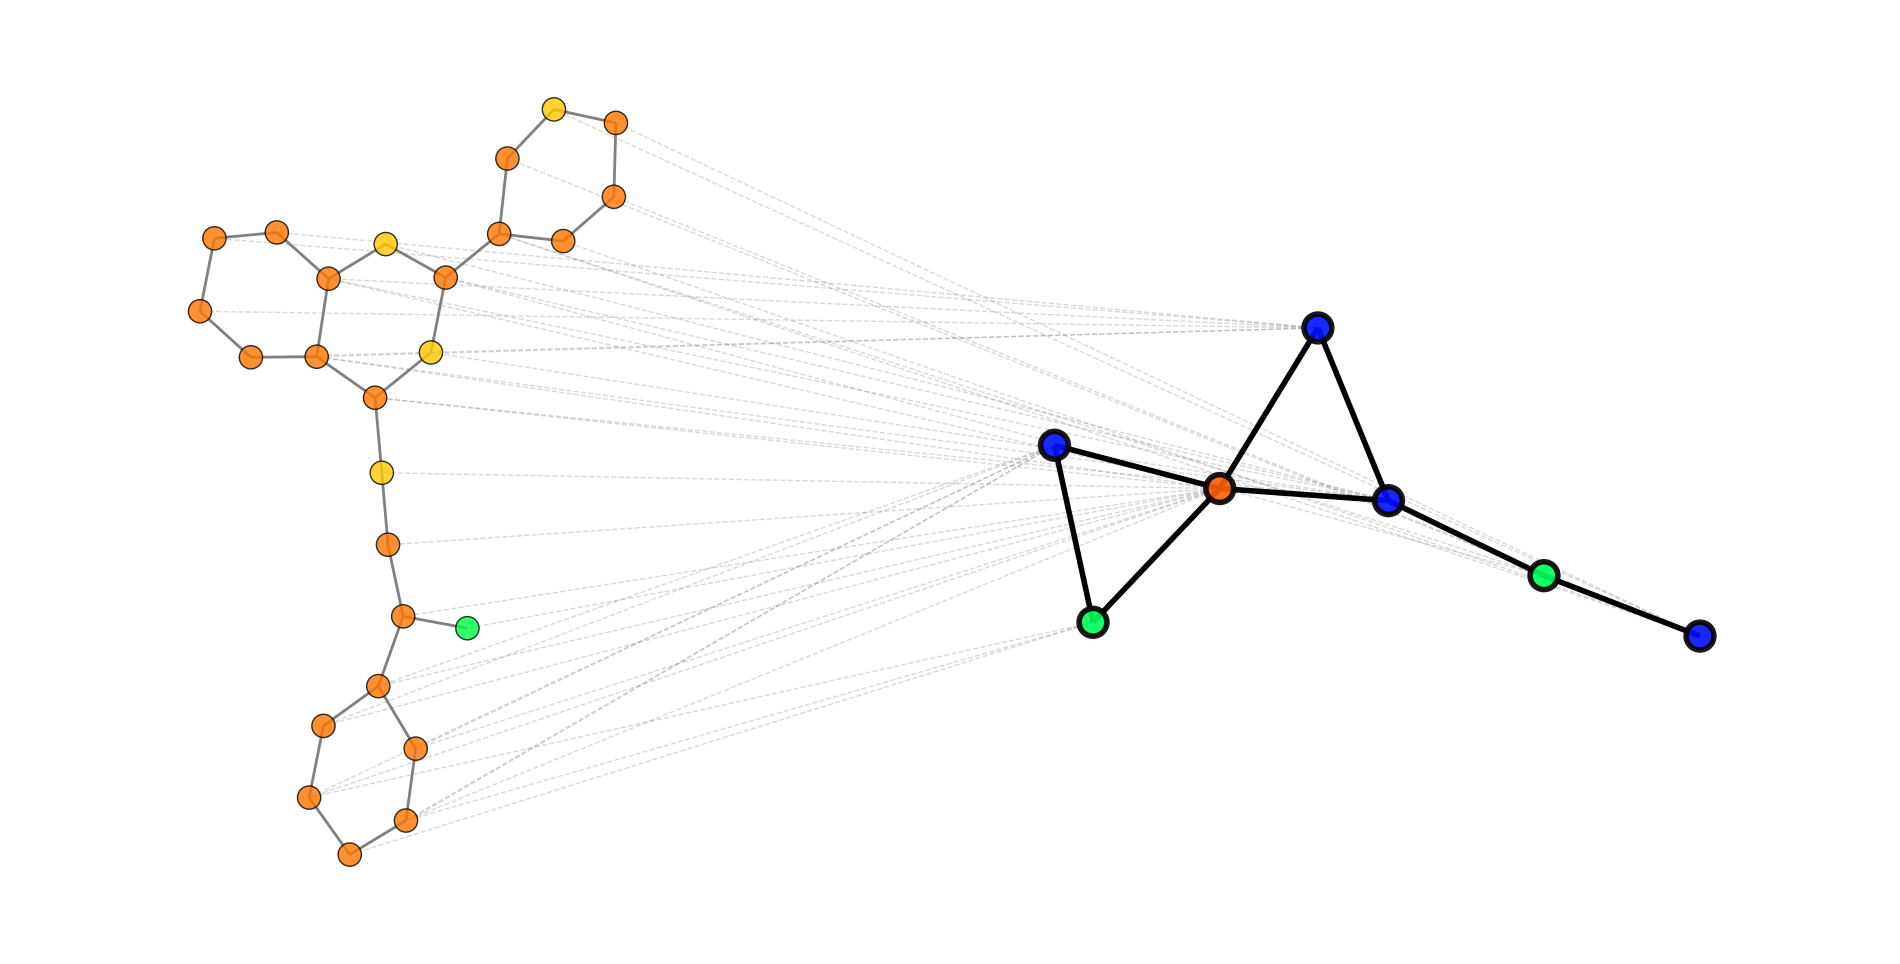

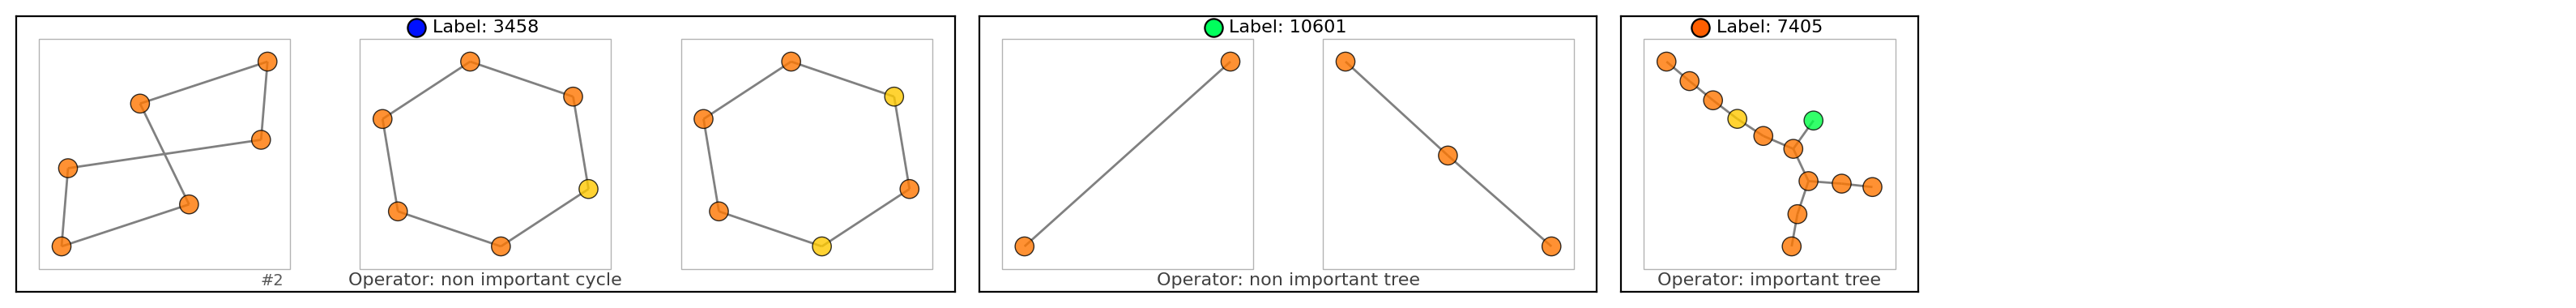

In [116]:
core_df = compose(connected_components_from_feature_ranking(
        ranked_features=ranked_feature_ids,
        max_num_base_nodes=12,
        node_agg='sum',
        min_component_size=1,
    ),
    df)
important_cycle_df = compose(name('important cycle'), cycle(), core_df)
important_tree_df = compose(name('important tree'), tree(), core_df)
non_important_cycle_df = compose(name('non important cycle'), cycle(), connected_component(), edge_complement(), merge(), important_cycle_df)
non_important_tree_df = compose(name('non important tree'),  tree(), connected_component(), edge_complement(), merge(), important_tree_df)
disp_df = compose(intersection_edges(), add(non_important_cycle_df, non_important_tree_df, important_tree_df, important_cycle_df))
component_ag = draw(
    example_graph,
    disp_df,
    nbits=graph_estimator.transformer.nbits,
    label_mode="graph_hash",
    display_label_mode="operator_hash",
)